In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

In [2]:
# loading the dataset to a Pandas DataFrame
df = pd.read_csv('../data/raw/creditcard.csv')

In [3]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [4]:
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 269967 entries, 0 to 269966
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    269967 non-null  float64
 1   V1      269967 non-null  float64
 2   V2      269967 non-null  float64
 3   V3      269967 non-null  float64
 4   V4      269967 non-null  float64
 5   V5      269967 non-null  float64
 6   V6      269967 non-null  float64
 7   V7      269967 non-null  float64
 8   V8      269967 non-null  float64
 9   V9      269967 non-null  float64
 10  V10     269967 non-null  float64
 11  V11     269967 non-null  float64
 12  V12     269967 non-null  float64
 13  V13     269967 non-null  float64
 14  V14     269967 non-null  float64
 15  V15     269967 non-null  float64
 16  V16     269967 non-null  float64
 17  V17     269967 non-null  float64
 18  V18     269967 non-null  float64
 19  V19     269967 non-null  float64
 20  V20     269967 non-null  float64
 21  V21     269967 non-nu

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000,...,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000,269967.000000
mean,90798.748814,-0.009476,-0.013283,0.041752,0.009085,-0.016358,0.006989,-0.007064,-0.000251,0.000408,...,-0.000121,-0.004036,-0.002052,0.000860,0.008135,0.000388,-0.000213,0.000555,89.409451,0.001782
std,45490.042112,1.957592,1.655926,1.509900,1.415991,1.367356,1.324728,1.219497,1.190799,1.103689,...,0.736789,0.722294,0.630161,0.605785,0.518431,0.483723,0.399091,0.332320,247.829871,0.042173
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,52560.000000,-0.923481,-0.606529,-0.823035,-0.845936,-0.708144,-0.760962,-0.559150,-0.206375,-0.648416,...,-0.226751,-0.538048,-0.163049,-0.352411,-0.307357,-0.328369,-0.070676,-0.052024,5.950000,0.000000
50%,81059.000000,0.017287,0.059833,0.231324,-0.005613,-0.073307,-0.264339,0.030966,0.024239,-0.053080,...,-0.029963,0.004190,-0.013811,0.042984,0.030888,-0.055244,0.001670,0.012246,22.630000,0.000000
75%,134347.000000,1.295719,0.789526,1.058966,0.764549,0.591652,0.407919,0.560143,0.327114,0.602275,...,0.182673,0.516909,0.143173,0.436829,0.356020,0.243546,0.089757,0.077848,78.850000,0.000000
max,163864.000000,2.454930,22.057729,9.382558,16.875344,34.801666,22.529298,36.877368,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Train Test and Split

# Decision Tress

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X = df.drop('Class',axis=1)
y = df['Class']

In [32]:
# 4. Scale Amount & Time
scaler = StandardScaler()
X["Amount"] = scaler.fit_transform(X[["Amount"]])
X["Time"] = scaler.fit_transform(X[["Time"]])


In [33]:
# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [34]:
# 6. Handle Imbalance (SMOT)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Class
0    188639
1       337
Name: count, dtype: int64
After SMOTE: Class
0    188639
1    188639
Name: count, dtype: int64


In [35]:
# 7. Train Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [36]:
# 8. Prediction with Threshold Tuning
y_probs = model.predict_proba(X_test)[:, 1]

# Change threshold here (IMPORTANT)
threshold = 0.6
y_pred = (y_probs >= threshold).astype(int)

In [37]:
# 9. Evaluation
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nROC AUC Score:", roc_auc_score(y_test, y_probs))

Confusion Matrix:

[[80793    54]
 [   26   118]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     80847
           1       0.69      0.82      0.75       144

    accuracy                           1.00     80991
   macro avg       0.84      0.91      0.87     80991
weighted avg       1.00      1.00      1.00     80991


ROC AUC Score: 0.9864219692065809


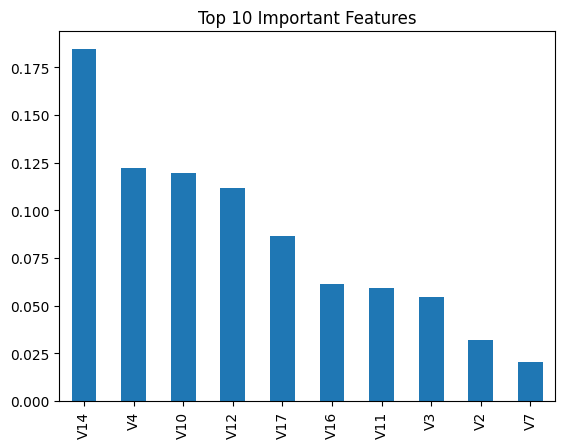

In [38]:
# 10. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

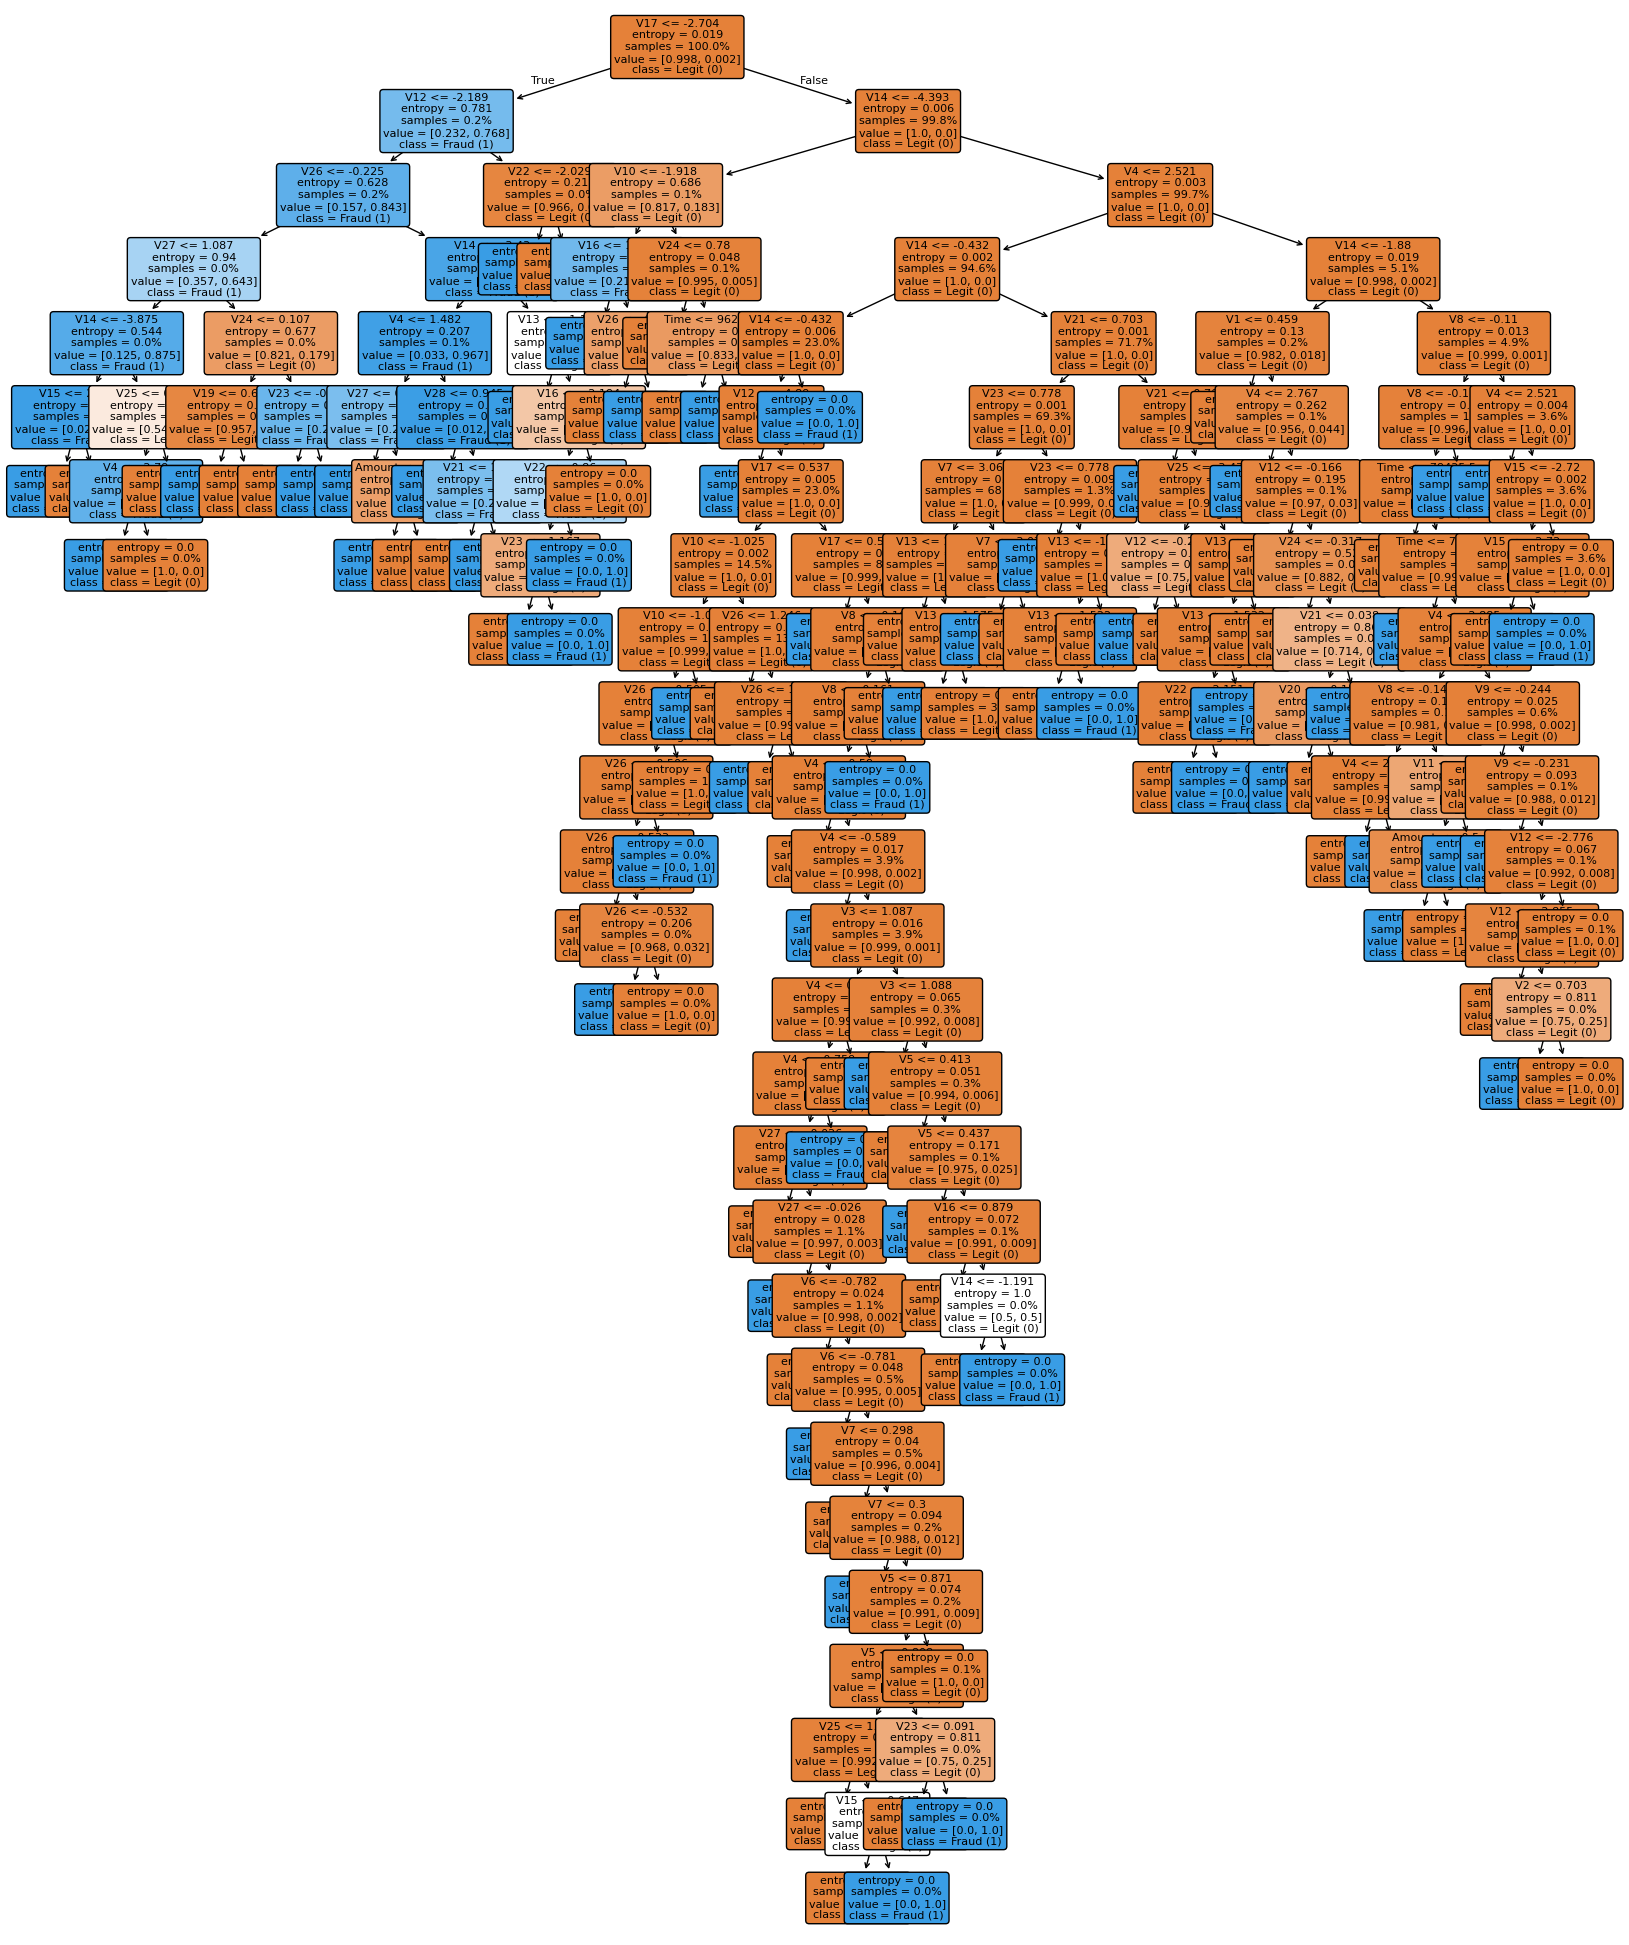

In [39]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,25))

tree.plot_tree(
    dtree,
    feature_names=X.columns,
    class_names=['Legit (0)', 'Fraud (1)'],  # Correct order
    rounded=True,
    filled=True,
    proportion=True,
    fontsize=8
)

plt.show()
